# MathVision Hybrid Matchmaking Engine

This notebook documents and demonstrates the **actual matching engine** used by the MathVision web application.

The engine combines:
1. A **rule-based score** — weighted compatibility across curriculum, grade, topic, branch, and tutor rating
2. A **predicted success probability** — tutor's historical success rate boosted by years of experience
3. A **hybrid final score** — 60% rule score + 40% predicted success probability
4. **Integer Programming** (via PuLP/CBC) — optimal whole-class assignment respecting tutor capacity constraints

The pipeline runs live in the FastAPI backend (`api/services/`) and persists results to a SQLite database.

## 1) Imports and setup

In [1]:
import sqlite3
import json
import uuid
from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import pulp

print('PuLP version:', pulp.__version__)
print('Solver available:', pulp.PULP_CBC_CMD().available())

PuLP version: 3.3.0
Solver available: /opt/anaconda3/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc


## 2) Data models

Mirrors `api/models.py` — the Pydantic models used by the web app.

In [2]:
from dataclasses import dataclass, field
from typing import Literal

@dataclass
class StudentProfile:
    student_id: str
    name: str
    curriculum: str          # 'Local' | 'IGCSE' | 'IB'
    grade_level: int         # 5–12
    weak_topic: str          # 'Fractions' | 'Algebra' | 'Geometry' | 'Calculus' | 'Statistics'
    branch: str              # 'Central' | 'East' | 'West'
    availability_slots: list

@dataclass
class TutorProfile:
    tutor_id: str
    name: str
    tutor_type: str          # 'part-time' | 'full-time' | 'instructor'
    primary_curriculum: str
    specialty_topic: str
    years_experience: int
    rating: float            # 1.0–5.0
    preferred_min_grade: int
    preferred_max_grade: int
    past_success_rate: float # 0.0–1.0
    branch: str
    availability_slots: list
    max_students_per_slot: int = 1

@dataclass
class PairingRecord:
    pairing_id: str
    student_id: str
    tutor_id: str
    time_slot: str
    satisfaction_score: float  # 0–100
    tutor_utilisation: float   # percentage
    matched_at: str            # ISO-8601

print('Data models defined.')

Data models defined.


## 3) Hybrid scorer

Mirrors `api/services/hybrid_scorer.py`.

### Rule score components (weights sum to 100)
| Component | Weight |
|---|---|
| Curriculum match | 30 |
| Grade overlap | 25 |
| Topic match | 25 |
| Branch match | 10 |
| Tutor rating (normalised) | 10 |

### Predicted success probability
Uses the tutor's `past_success_rate` as a base, boosted by up to 10% for experience (capped at 10 years).

### Final hybrid score
```
final_score = 0.6 × rule_score + 0.4 × predicted_success_probability
```

In [3]:
def rule_score(student: StudentProfile, tutor: TutorProfile) -> float:
    """Compute the rule-based match score (0–100)."""
    curriculum_match = 1.0 if tutor.primary_curriculum == student.curriculum else 0.0
    grade_overlap = (
        1.0 if tutor.preferred_min_grade <= student.grade_level <= tutor.preferred_max_grade
        else 0.0
    )
    topic_match = 1.0 if tutor.specialty_topic == student.weak_topic else 0.0
    branch_match = 1.0 if tutor.branch == student.branch else 0.5
    rating_score = (tutor.rating - 1.0) / 4.0  # normalised 0–1

    return (
        curriculum_match * 30
        + grade_overlap   * 25
        + topic_match     * 25
        + branch_match    * 10
        + rating_score    * 10
    )


def predicted_success_probability(student: StudentProfile, tutor: TutorProfile) -> float:
    """Estimate probability of a successful pairing (0–100)."""
    base = tutor.past_success_rate
    experience_boost = min(tutor.years_experience / 10.0, 1.0) * 0.1
    return min(base + experience_boost, 1.0) * 100


def final_score(student: StudentProfile, tutor: TutorProfile) -> float:
    """Hybrid final score: 60% rule + 40% predicted success probability."""
    return 0.6 * rule_score(student, tutor) + 0.4 * predicted_success_probability(student, tutor)


print('Hybrid scorer functions defined.')

Hybrid scorer functions defined.


## 4) Availability grouping

Mirrors `api/services/matching_service.group_by_availability()`.

Groups students and tutors by shared time slots. Only slots with at least one student **and** one tutor qualify. Students with no overlap are flagged as unmatched.

In [4]:
@dataclass
class AvailabilityGroup:
    time_slot: str
    students: list = field(default_factory=list)
    tutors: list = field(default_factory=list)


def group_by_availability(students, tutors):
    """Group students and tutors by shared availability slots."""
    tutor_slots = set()
    for tutor in tutors:
        tutor_slots.update(tutor.availability_slots)

    slot_students = {}
    slot_tutors = {}

    for tutor in tutors:
        for slot in tutor.availability_slots:
            slot_tutors.setdefault(slot, []).append(tutor)

    for student in students:
        for slot in student.availability_slots:
            if slot in tutor_slots:
                slot_students.setdefault(slot, []).append(student)

    qualifying_slots = set(slot_students.keys()) & set(slot_tutors.keys())

    groups = [
        AvailabilityGroup(
            time_slot=slot,
            students=slot_students[slot],
            tutors=slot_tutors[slot],
        )
        for slot in sorted(qualifying_slots)
    ]

    matched_ids = {
        s.student_id
        for slot in qualifying_slots
        for s in slot_students[slot]
    }
    unmatched = [s.student_id for s in students if s.student_id not in matched_ids]

    return groups, unmatched


print('Availability grouping defined.')

Availability grouping defined.


## 5) Integer Programming assignment

Mirrors `api/services/matching_service.score_group()`.

For each availability group, formulates and solves an **Integer Programming** problem using PuLP (CBC solver):

- **Decision variables**: binary $x_{ij}$ — assign student $i$ to tutor $j$
- **Objective**: maximise $\sum_{i,j} \text{score}_{ij} \cdot x_{ij}$ (with a tiny utilisation tie-breaker)
- **Constraints**:
  - Each student assigned to at most one tutor
  - Each tutor assigned at most `max_students_per_slot` students

In [5]:
@dataclass
class ScoredPairing:
    student_id: str
    tutor_id: str
    time_slot: str
    satisfaction_score: float
    tutor_utilisation: float


def score_group(group: AvailabilityGroup, utilisation_map: dict = None) -> list:
    """
    Use Integer Programming to find the optimal assignment for an availability group.
    utilisation_map: {tutor_id: utilisation_pct} — defaults to 0 for all tutors.
    """
    students = group.students
    tutors = group.tutors
    if not students or not tutors:
        return []

    if utilisation_map is None:
        utilisation_map = {}

    # Build score matrix
    scores = {
        (i, j): final_score(students[i], tutors[j])
        for i in range(len(students))
        for j in range(len(tutors))
    }

    utilisations = [
        utilisation_map.get(tutor.tutor_id, 0.0) / 100.0
        for tutor in tutors
    ]

    prob = pulp.LpProblem('student_tutor_matching', pulp.LpMaximize)

    x = {
        (i, j): pulp.LpVariable(f'x_{i}_{j}', cat='Binary')
        for i in range(len(students))
        for j in range(len(tutors))
    }

    # Objective
    prob += pulp.lpSum(
        scores[(i, j)] * x[(i, j)]
        + 0.0001 * (1.0 - utilisations[j]) * x[(i, j)]
        for i in range(len(students))
        for j in range(len(tutors))
    )

    # Each student assigned to at most one tutor
    for i in range(len(students)):
        prob += pulp.lpSum(x[(i, j)] for j in range(len(tutors))) <= 1

    # Each tutor assigned at most capacity students
    for j, tutor in enumerate(tutors):
        prob += pulp.lpSum(x[(i, j)] for i in range(len(students))) <= tutor.max_students_per_slot

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    result = []
    for i, student in enumerate(students):
        for j, tutor in enumerate(tutors):
            if pulp.value(x[(i, j)]) == 1:
                result.append(ScoredPairing(
                    student_id=student.student_id,
                    tutor_id=tutor.tutor_id,
                    time_slot=group.time_slot,
                    satisfaction_score=scores[(i, j)],
                    tutor_utilisation=utilisations[j] * 100.0,
                ))
    return result


print('IP assignment solver defined.')

IP assignment solver defined.


## 6) Demo — run the full pipeline

Uses the same seed data as `api/seed.py`.

In [6]:
STUDENTS = [
    StudentProfile('s-001', 'Lucas Ong',   'IB',    11, 'Calculus',   'Central', ['Mon_09:00', 'Mon_09:30', 'Wed_14:00', 'Wed_14:30']),
    StudentProfile('s-002', 'Emma Lim',    'IGCSE', 10, 'Geometry',   'East',    ['Tue_10:00', 'Tue_10:30', 'Thu_16:00', 'Thu_16:30']),
    StudentProfile('s-003', 'Aiden Tan',   'Local',  8, 'Fractions',  'West',    ['Mon_14:00', 'Mon_14:30', 'Fri_09:00', 'Fri_09:30']),
    StudentProfile('s-004', 'Priya Nair',  'IGCSE',  9, 'Algebra',    'Central', ['Wed_09:00', 'Wed_09:30', 'Sat_10:00', 'Sat_10:30']),
    StudentProfile('s-005', 'Marcus Wong', 'IB',    12, 'Statistics', 'East',    ['Tue_14:00', 'Tue_14:30', 'Thu_09:00', 'Thu_09:30']),
]

TUTORS = [
    TutorProfile('t-001', 'Ms Hafizah Rahman',    'full-time',  'Local',  'Fractions',  6, 4.7, 5,  9,  0.88, 'Central', ['Mon_09:00','Mon_09:30','Mon_14:00','Mon_14:30','Wed_09:00','Wed_09:30','Wed_14:00','Wed_14:30']),
    TutorProfile('t-002', 'Mr Kevin Tan',         'full-time',  'IGCSE',  'Algebra',    8, 4.5, 8,  12, 0.91, 'East',    ['Tue_10:00','Tue_10:30','Tue_14:00','Tue_14:30','Thu_09:00','Thu_09:30','Thu_16:00','Thu_16:30','Sat_10:00','Sat_10:30']),
    TutorProfile('t-003', 'Ms Priscilla Goh',     'part-time',  'IB',     'Calculus',   4, 4.3, 10, 12, 0.82, 'Central', ['Mon_09:00','Mon_09:30','Wed_14:00','Wed_14:30','Tue_14:00','Tue_14:30']),
    TutorProfile('t-004', 'Mr Darren Lim',        'instructor', 'IGCSE',  'Geometry',  10, 4.8, 7,  11, 0.93, 'East',    ['Tue_10:00','Tue_10:30','Thu_16:00','Thu_16:30','Sat_10:00','Sat_10:30']),
    TutorProfile('t-005', 'Ms Aisha Binte Yusof', 'part-time',  'Local',  'Statistics', 3, 4.1, 5,  10, 0.78, 'West',    ['Mon_14:00','Mon_14:30','Fri_09:00','Fri_09:30','Fri_14:00','Fri_14:30']),
]

print(f'{len(STUDENTS)} students, {len(TUTORS)} tutors loaded.')

5 students, 5 tutors loaded.


In [7]:
# Step 1: group by availability
groups, unmatched = group_by_availability(STUDENTS, TUTORS)
print(f'{len(groups)} availability groups found')
print(f'Unmatched students: {unmatched}')
for g in groups:
    print(f'  {g.time_slot}: {len(g.students)} student(s), {len(g.tutors)} tutor(s)')

20 availability groups found
Unmatched students: []
  Fri_09:00: 1 student(s), 1 tutor(s)
  Fri_09:30: 1 student(s), 1 tutor(s)
  Mon_09:00: 1 student(s), 2 tutor(s)
  Mon_09:30: 1 student(s), 2 tutor(s)
  Mon_14:00: 1 student(s), 2 tutor(s)
  Mon_14:30: 1 student(s), 2 tutor(s)
  Sat_10:00: 1 student(s), 2 tutor(s)
  Sat_10:30: 1 student(s), 2 tutor(s)
  Thu_09:00: 1 student(s), 1 tutor(s)
  Thu_09:30: 1 student(s), 1 tutor(s)
  Thu_16:00: 1 student(s), 2 tutor(s)
  Thu_16:30: 1 student(s), 2 tutor(s)
  Tue_10:00: 1 student(s), 2 tutor(s)
  Tue_10:30: 1 student(s), 2 tutor(s)
  Tue_14:00: 1 student(s), 2 tutor(s)
  Tue_14:30: 1 student(s), 2 tutor(s)
  Wed_09:00: 1 student(s), 1 tutor(s)
  Wed_09:30: 1 student(s), 1 tutor(s)
  Wed_14:00: 1 student(s), 2 tutor(s)
  Wed_14:30: 1 student(s), 2 tutor(s)


In [8]:
# Step 2: run IP solver for each group
all_pairings = []
for group in groups:
    pairings = score_group(group)
    all_pairings.extend(pairings)

print(f'\n{len(all_pairings)} pairings produced:')
for p in all_pairings:
    student = next(s for s in STUDENTS if s.student_id == p.student_id)
    tutor   = next(t for t in TUTORS   if t.tutor_id   == p.tutor_id)
    print(f'  {student.name} → {tutor.name} @ {p.time_slot}  score={p.satisfaction_score:.1f}')


20 pairings produced:
  Aiden Tan → Ms Aisha Binte Yusof @ Fri_09:00  score=76.0
  Aiden Tan → Ms Aisha Binte Yusof @ Fri_09:30  score=76.0
  Lucas Ong → Ms Priscilla Goh @ Mon_09:00  score=93.3
  Lucas Ong → Ms Priscilla Goh @ Mon_09:30  score=93.3
  Aiden Tan → Ms Hafizah Rahman @ Mon_14:00  score=94.2
  Aiden Tan → Ms Hafizah Rahman @ Mon_14:30  score=94.2
  Priya Nair → Mr Kevin Tan @ Sat_10:00  score=95.8
  Priya Nair → Mr Kevin Tan @ Sat_10:30  score=95.8
  Marcus Wong → Mr Kevin Tan @ Thu_09:00  score=65.8
  Marcus Wong → Mr Kevin Tan @ Thu_09:30  score=65.8
  Emma Lim → Mr Darren Lim @ Thu_16:00  score=99.7
  Emma Lim → Mr Darren Lim @ Thu_16:30  score=99.7
  Emma Lim → Mr Darren Lim @ Tue_10:00  score=99.7
  Emma Lim → Mr Darren Lim @ Tue_10:30  score=99.7
  Marcus Wong → Ms Priscilla Goh @ Tue_14:00  score=75.3
  Marcus Wong → Ms Priscilla Goh @ Tue_14:30  score=75.3
  Priya Nair → Ms Hafizah Rahman @ Wed_09:00  score=64.2
  Priya Nair → Ms Hafizah Rahman @ Wed_09:30  score=

## 7) Ranking output

All pairings ranked by final score descending, with a full score breakdown.

In [9]:
ranking_rows = []
for rank, p in enumerate(
    sorted(all_pairings, key=lambda x: x.satisfaction_score, reverse=True), start=1
):
    student = next(s for s in STUDENTS if s.student_id == p.student_id)
    tutor   = next(t for t in TUTORS   if t.tutor_id   == p.tutor_id)
    rs  = rule_score(student, tutor)
    psp = predicted_success_probability(student, tutor)
    ranking_rows.append({
        'rank':                   rank,
        'student':                student.name,
        'tutor':                  tutor.name,
        'time_slot':              p.time_slot,
        'rule_score':             round(rs, 2),
        'predicted_success_prob': round(psp, 2),
        'final_score':            round(p.satisfaction_score, 2),
        'curriculum_match':       tutor.primary_curriculum == student.curriculum,
        'topic_match':            tutor.specialty_topic == student.weak_topic,
        'branch_match':           tutor.branch == student.branch,
        'grade_in_range':         tutor.preferred_min_grade <= student.grade_level <= tutor.preferred_max_grade,
    })

ranking_df = pd.DataFrame(ranking_rows).set_index('rank')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
display(ranking_df)

,student,tutor,time_slot,rule_score,predicted_success_prob,final_score,curriculum_match,topic_match,branch_match,grade_in_range
rank,,,,,,,,,,
1,Emma Lim,Mr Darren Lim,Thu_16:00,99.50,100.0,99.70,True,True,True,True
2,Emma Lim,Mr Darren Lim,Thu_16:30,99.50,100.0,99.70,True,True,True,True
3,Emma Lim,Mr Darren Lim,Tue_10:00,99.50,100.0,99.70,True,True,True,True
4,Emma Lim,Mr Darren Lim,Tue_10:30,99.50,100.0,99.70,True,True,True,True
5,Priya Nair,Mr Kevin Tan,Sat_10:00,93.75,99.0,95.85,True,True,False,True
6,Priya Nair,Mr Kevin Tan,Sat_10:30,93.75,99.0,95.85,True,True,False,True
7,Aiden Tan,Ms Hafizah Rahman,Mon_14:00,94.25,94.0,94.15,True,True,False,True
8,Aiden Tan,Ms Hafizah Rahman,Mon_14:30,94.25,94.0,94.15,True,True,False,True
9,Lucas Ong,Ms Priscilla Goh,Mon_09:00,98.25,86.0,93.35,True,True,True,True


## 8) Score breakdown visualisation

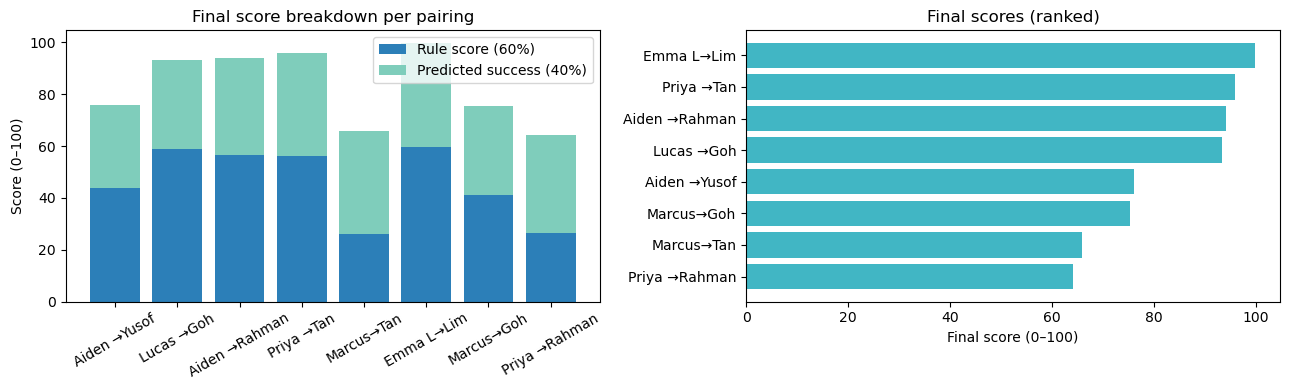

In [10]:
if all_pairings:
    rows = []
    for p in all_pairings:
        student = next(s for s in STUDENTS if s.student_id == p.student_id)
        tutor   = next(t for t in TUTORS   if t.tutor_id   == p.tutor_id)
        rs = rule_score(student, tutor)
        psp = predicted_success_probability(student, tutor)
        rows.append({
            'pair': f'{student.name[:6]}→{tutor.name.split()[-1]}',
            'rule_score': rs,
            'predicted_success': psp,
            'final_score': p.satisfaction_score,
        })

    df = pd.DataFrame(rows)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Stacked bar: rule vs predicted success contribution
    ax = axes[0]
    rule_contrib = df['rule_score'] * 0.6
    psp_contrib  = df['predicted_success'] * 0.4
    ax.bar(df['pair'], rule_contrib, label='Rule score (60%)', color='#2c7fb8')
    ax.bar(df['pair'], psp_contrib, bottom=rule_contrib, label='Predicted success (40%)', color='#7fcdbb')
    ax.set_title('Final score breakdown per pairing')
    ax.set_ylabel('Score (0–100)')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

    # Final scores ranked
    ax2 = axes[1]
    df_sorted = df.sort_values('final_score', ascending=True)
    ax2.barh(df_sorted['pair'], df_sorted['final_score'], color='#41b6c4')
    ax2.set_title('Final scores (ranked)')
    ax2.set_xlabel('Final score (0–100)')

    plt.tight_layout()
    plt.show()
else:
    print('No pairings to visualise.')

## 8) Scorer correctness checks

In [11]:
# Perfect match: same curriculum, topic, branch, grade in range, high rating
perfect_student = StudentProfile('test-s', 'Test', 'IB', 11, 'Calculus', 'Central', [])
perfect_tutor   = TutorProfile('test-t', 'Test', 'full-time', 'IB', 'Calculus', 10, 5.0, 10, 12, 1.0, 'Central', [])
assert rule_score(perfect_student, perfect_tutor) == 100.0, 'Perfect rule score should be 100'

# Predicted success: capped at 100
psp = predicted_success_probability(perfect_student, perfect_tutor)
assert psp == 100.0, f'Expected 100, got {psp}'

# Final score: 0.6*100 + 0.4*100 = 100
fs = final_score(perfect_student, perfect_tutor)
assert fs == 100.0, f'Expected 100, got {fs}'

# Branch mismatch reduces rule score
diff_branch_tutor = TutorProfile('test-t2', 'Test', 'full-time', 'IB', 'Calculus', 10, 5.0, 10, 12, 1.0, 'East', [])
rs_diff = rule_score(perfect_student, diff_branch_tutor)
assert rs_diff < 100.0, 'Different branch should reduce rule score'

# IP solver: each student assigned at most once
group = AvailabilityGroup('Mon_09:00', students=STUDENTS[:3], tutors=TUTORS[:3])
pairings = score_group(group)
assigned_students = [p.student_id for p in pairings]
assert len(assigned_students) == len(set(assigned_students)), 'Each student assigned at most once'

print('All correctness checks passed.')

All correctness checks passed.
